<div style="background:linear-gradient(135deg,#0d1117,#1c2940);padding:44px 36px;border-radius:16px;border:1px solid #30363d;text-align:center;">
  <h1 style="color:#e6edf3;font-size:2.4em;margin-bottom:8px;">📊 Probability Distributions</h1>
  <h3 style="color:#58a6ff;font-weight:400;margin-bottom:16px;">A Complete Visual Lecture — Random Variables to t-Distribution</h3>
  <p style="color:#8b949e;font-size:1.05em;max-width:700px;margin:0 auto;line-height:2;">
    We start from scratch — what is a random variable? — and build through
    <strong style="color:#e6edf3">7 distributions</strong>, each explained with plain English, real examples, and visual intuition.
  </p>
</div>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
from scipy import stats
import warnings; warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams.update({'figure.dpi':110,'font.family':'DejaVu Sans',
                     'axes.spines.top':False,'axes.spines.right':False})

BG,PANEL,GRID = '#0d1117','#161b22','#21262d'
TXT,DIM,BDR   = '#e6edf3','#8b949e','#30363d'
C = dict(bernoulli='#ff6b6b',binomial='#ff9f43',normal='#48dbfb',
         poisson='#1dd1a1',uniform='#f368e0',exponential='#feca57',t='#a29bfe')

def ax_style(ax,title='',xlabel='',ylabel='',tc=None):
    tc = tc or TXT
    ax.set_facecolor(PANEL)
    for s in ax.spines.values(): s.set_color(BDR)
    ax.tick_params(colors=DIM,labelsize=9)
    ax.xaxis.label.set_color(DIM); ax.yaxis.label.set_color(DIM)
    ax.grid(color=GRID,linestyle='--',linewidth=0.6,alpha=0.8)
    if title:  ax.set_title(title, color=tc,fontsize=12,fontweight='bold',pad=10)
    if xlabel: ax.set_xlabel(xlabel,color=DIM,fontsize=10)
    if ylabel: ax.set_ylabel(ylabel,color=DIM,fontsize=10)

np.random.seed(42)
print('Ready!')

Ready!


---
# Chapter 0 — What is a Random Variable?

A **random variable** is a number whose value we do not know in advance — it depends on the outcome of some random experiment.

**Examples:**

| Experiment | Random Variable X | Possible values |
|---|---|---|
| Roll a die | Number that shows up | 1, 2, 3, 4, 5, 6 |
| Toss a coin | 1 = heads, 0 = tails | 0 or 1 |
| Measure a student's height | Height in cm | ~140–210 cm |
| Count emails in an hour | Number of emails | 0, 1, 2, 3, … |

**Discrete** random variables take whole-number values (die, coin, email count).  
**Continuous** random variables take any real value in a range (height, weight, time).

A **probability distribution** is the rulebook: *how likely is each possible value?*

| Type | Probability description | Visual |
|---|---|---|
| Discrete | PMF — exact probability P(X = k) | Bar chart |
| Continuous | PDF — probability of interval = area | Smooth curve |

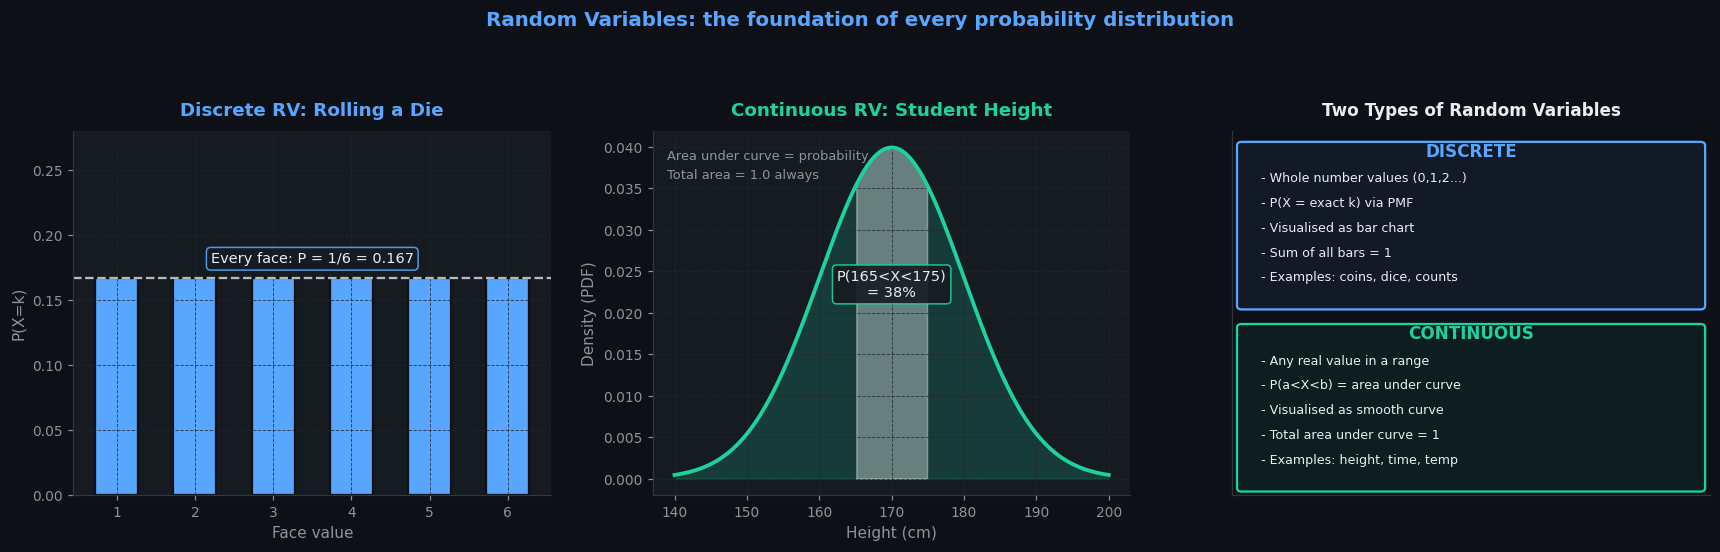

In [2]:
fig, axes = plt.subplots(1,3,figsize=(16,5),facecolor=BG)
fig.patch.set_facecolor(BG)

# Die — discrete
ax = axes[0]
ax_style(ax,title='Discrete RV: Rolling a Die',xlabel='Face value',ylabel='P(X=k)',tc='#58a6ff')
ax.bar(range(1,7),[1/6]*6,color='#58a6ff',edgecolor=BG,linewidth=1.5,width=0.55)
ax.axhline(1/6,color='white',linewidth=1.5,linestyle='--',alpha=0.7)
ax.text(3.5,1/6+0.012,f'Every face: P = 1/6 = {1/6:.3f}',ha='center',color=TXT,fontsize=9.5,
        bbox=dict(boxstyle='round,pad=0.3',facecolor=PANEL,edgecolor='#58a6ff',alpha=0.9))
ax.set_xticks(range(1,7)); ax.set_ylim(0,0.28)

# Height — continuous
ax = axes[1]
ax_style(ax,title='Continuous RV: Student Height',xlabel='Height (cm)',ylabel='Density (PDF)',tc='#1dd1a1')
x = np.linspace(140,200,400)
pdf = stats.norm.pdf(x,170,10)
ax.plot(x,pdf,color='#1dd1a1',linewidth=2.5)
ax.fill_between(x,pdf,color='#1dd1a1',alpha=0.18)
mask = (x>=165)&(x<=175)
ax.fill_between(x[mask],pdf[mask],color='white',alpha=0.35)
area = stats.norm.cdf(175,170,10)-stats.norm.cdf(165,170,10)
ax.text(170,stats.norm.pdf(170,170,10)*0.55,f'P(165<X<175)\n= {area:.0%}',
        ha='center',color=TXT,fontsize=9.5,
        bbox=dict(boxstyle='round,pad=0.3',facecolor=PANEL,edgecolor='#1dd1a1',alpha=0.9))
ax.text(0.03,0.95,'Area under curve = probability\nTotal area = 1.0 always',
        transform=ax.transAxes,va='top',color=DIM,fontsize=8.5,linespacing=1.6)

# Summary panel
ax = axes[2]; ax.set_facecolor('#0d1117')
for s in ax.spines.values(): s.set_color(BDR)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title('Two Types of Random Variables',color=TXT,fontsize=11,fontweight='bold',pad=10)
info = [
    ('DISCRETE','#58a6ff',
     ['Whole number values (0,1,2...)',
      'P(X = exact k) via PMF',
      'Visualised as bar chart',
      'Sum of all bars = 1',
      'Examples: coins, dice, counts']),
    ('CONTINUOUS','#1dd1a1',
     ['Any real value in a range',
      'P(a<X<b) = area under curve',
      'Visualised as smooth curve',
      'Total area under curve = 1',
      'Examples: height, time, temp']),
]
for ci,(label,color,bullets) in enumerate(info):
    y0 = 0.97 - ci*0.50
    ax.add_patch(FancyBboxPatch((0.02,y0-0.45),0.96,0.44,
                                boxstyle='round,pad=0.01',
                                facecolor=color+'11',edgecolor=color,
                                linewidth=1.5,transform=ax.transAxes))
    ax.text(0.50,y0-0.04,label,transform=ax.transAxes,
            ha='center',color=color,fontsize=11,fontweight='bold')
    for bi,b in enumerate(bullets):
        ax.text(0.06,y0-0.11-bi*0.068,f'- {b}',transform=ax.transAxes,
                color=TXT,fontsize=8.3,linespacing=1.3)

fig.suptitle('Random Variables: the foundation of every probability distribution',
             color='#58a6ff',fontsize=13,fontweight='bold',y=1.02)
plt.tight_layout(pad=2); plt.show()

---
# Chapter 1 — Bernoulli Distribution

## What is it?

The Bernoulli distribution is the **simplest distribution possible**. It describes a single experiment with exactly **two outcomes**: success (1) or failure (0).

Think of it like a **single coin flip** — you either get heads or tails. That's it.

**Formula:**
- P(X = 1) = p   (probability of success)
- P(X = 0) = 1−p (probability of failure)

Only **one parameter** — `p`, the probability of success.

| Property | Value | Intuition |
|---|---|---|
| Mean | p | On average you succeed p fraction of trials |
| Variance | p(1−p) | Maximum spread at p=0.5 (most uncertain) |
| Min variance | at p=0 or p=1 | Completely predictable — no uncertainty |

## When to use it?

Use Bernoulli whenever you have **one trial** with **two outcomes** and you know (or estimate) the probability of success.

## Real-world Examples

| Scenario | Success (1) | p |
|---|---|---|
| Flip a fair coin | Heads | 0.50 |
| Patient recovers after treatment | Recovers | 0.70 |
| Manufactured part passes quality check | Pass | 0.95 |
| Random email is spam | It is spam | 0.30 |

## Key Insight

- p = 0.5 → perfectly uncertain, highest possible variance (a fair coin)
- p close to 0 or 1 → very predictable, low variance
- **Bernoulli is the building block** — repeat it N times and you get Binomial!

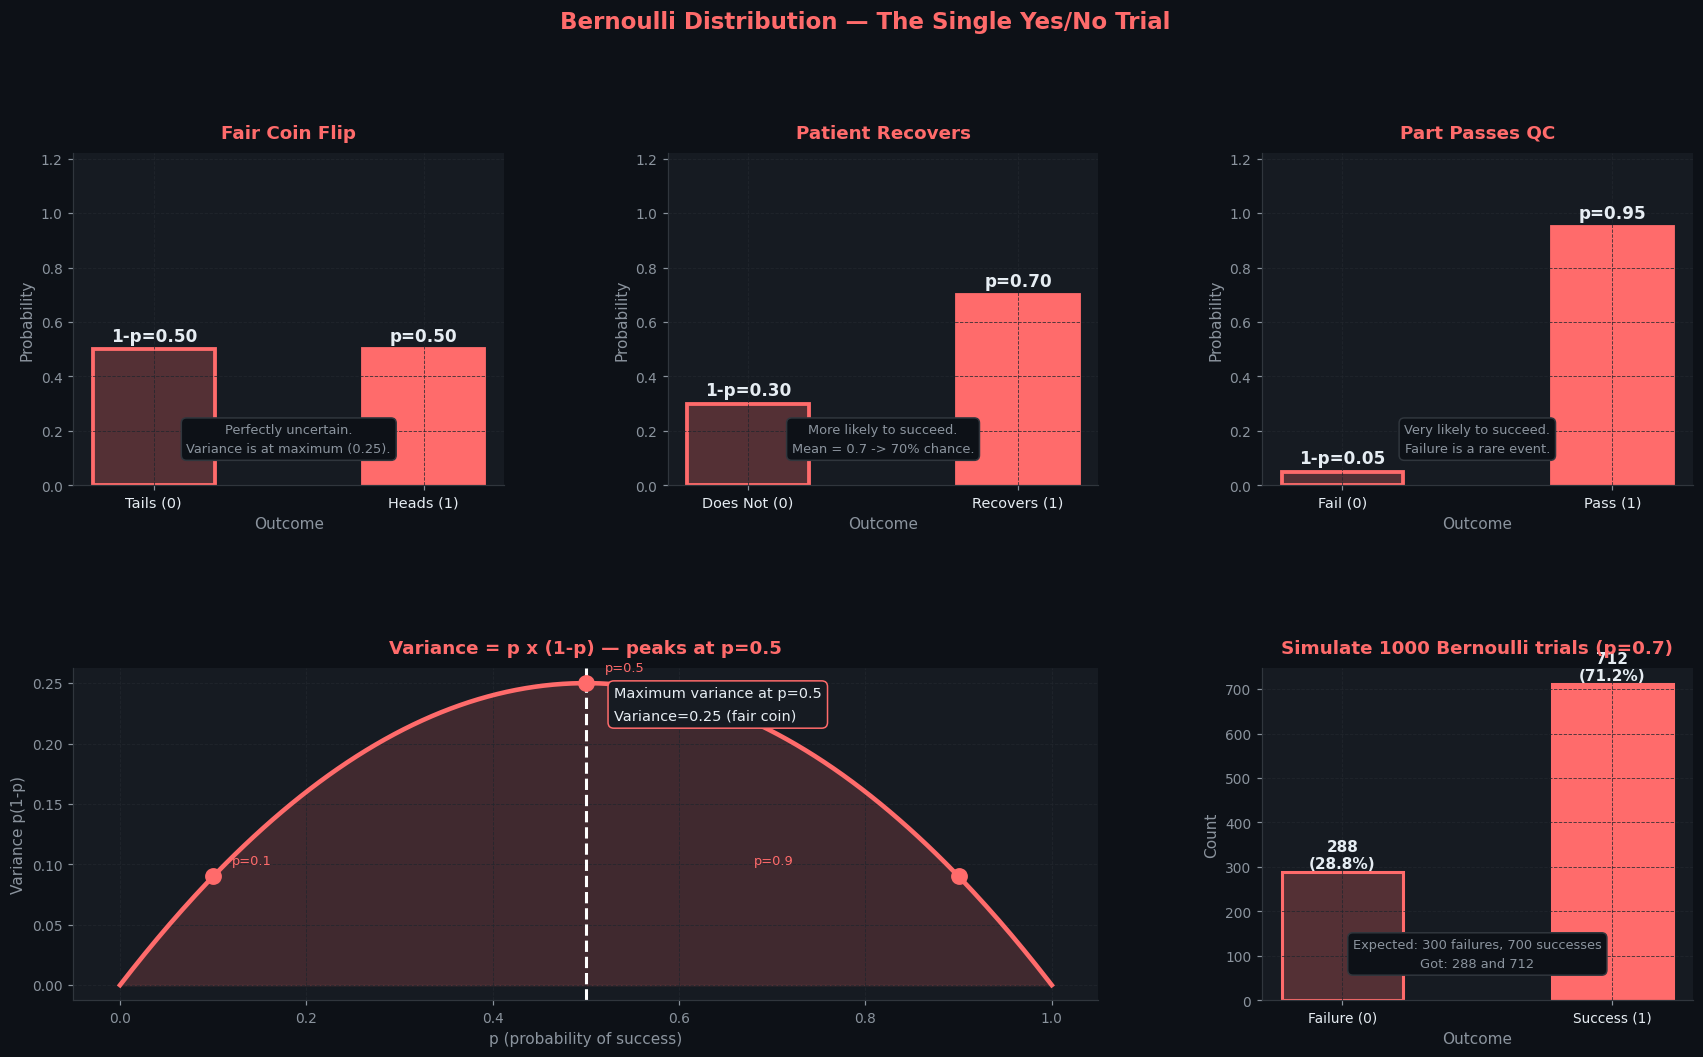

In [3]:
fig = plt.figure(figsize=(16,10),facecolor=BG)
fig.patch.set_facecolor(BG)
fig.suptitle('Bernoulli Distribution — The Single Yes/No Trial',
             color=C['bernoulli'],fontsize=15,fontweight='bold',y=1.01)
gs = gridspec.GridSpec(2,3,figure=fig,hspace=0.55,wspace=0.38,left=0.05,right=0.97)

examples = [
    dict(p=0.50,label='Fair Coin Flip',
         s_name='Heads (1)',f_name='Tails (0)',
         note='Perfectly uncertain.\nVariance is at maximum (0.25).'),
    dict(p=0.70,label='Patient Recovers',
         s_name='Recovers (1)',f_name='Does Not (0)',
         note='More likely to succeed.\nMean = 0.7 -> 70% chance.'),
    dict(p=0.95,label='Part Passes QC',
         s_name='Pass (1)',f_name='Fail (0)',
         note='Very likely to succeed.\nFailure is a rare event.'),
]
for i,ex in enumerate(examples):
    ax = fig.add_subplot(gs[0,i])
    p  = ex['p']
    ax_style(ax,title=ex['label'],xlabel='Outcome',ylabel='Probability',tc=C['bernoulli'])
    bars = ax.bar([0,1],[1-p,p],
                  color=[C['bernoulli']+'44',C['bernoulli']],
                  edgecolor=C['bernoulli'],linewidth=2.5,width=0.45)
    ax.set_xticks([0,1])
    ax.set_xticklabels([ex['f_name'],ex['s_name']],color=TXT,fontsize=9.5)
    ax.set_ylim(0,1.22)
    for bar,v,lbl in zip(bars,[1-p,p],[f'1-p={1-p:.2f}',f'p={p:.2f}']):
        ax.text(bar.get_x()+bar.get_width()/2,v+0.03,lbl,
                ha='center',color=TXT,fontsize=11,fontweight='bold')
    ax.text(0.5,0.10,ex['note'],transform=ax.transAxes,ha='center',
            color=DIM,fontsize=8.5,linespacing=1.6,
            bbox=dict(boxstyle='round,pad=0.4',facecolor=BG,edgecolor=BDR))

# Variance curve
ax = fig.add_subplot(gs[1,:2])
ax_style(ax,title='Variance = p x (1-p) — peaks at p=0.5',
         xlabel='p (probability of success)',ylabel='Variance p(1-p)',tc=C['bernoulli'])
p_range = np.linspace(0,1,300)
ax.plot(p_range,p_range*(1-p_range),color=C['bernoulli'],linewidth=3)
ax.fill_between(p_range,p_range*(1-p_range),color=C['bernoulli'],alpha=0.18)
ax.axvline(0.5,color='white',linewidth=2,linestyle='--')
ax.text(0.53,0.22,'Maximum variance at p=0.5\nVariance=0.25 (fair coin)',
        color=TXT,fontsize=9.5,linespacing=1.7,
        bbox=dict(boxstyle='round,pad=0.4',facecolor=PANEL,edgecolor=C['bernoulli']))
for pv,lbl,xo in [(0.1,'p=0.1',0.02),(0.5,'p=0.5',0.02),(0.9,'p=0.9',-0.22)]:
    v=pv*(1-pv)
    ax.plot(pv,v,'o',color=C['bernoulli'],markersize=10,zorder=5)
    ax.text(pv+xo,v+0.01,lbl,color=C['bernoulli'],fontsize=8.5)

# Simulation
ax = fig.add_subplot(gs[1,2])
ax_style(ax,title='Simulate 1000 Bernoulli trials (p=0.7)',
         xlabel='Outcome',ylabel='Count',tc=C['bernoulli'])
trials = np.random.binomial(1,0.7,1000)
counts = np.bincount(trials)
ax.bar([0,1],counts,color=[C['bernoulli']+'44',C['bernoulli']],
       edgecolor=C['bernoulli'],linewidth=2,width=0.45)
ax.set_xticks([0,1]); ax.set_xticklabels(['Failure (0)','Success (1)'],color=TXT)
for xi,ct in zip([0,1],counts):
    ax.text(xi,ct+8,f'{ct}\n({ct/10:.1f}%)',ha='center',color=TXT,fontsize=10,fontweight='bold')
ax.text(0.5,0.10,f'Expected: 300 failures, 700 successes\nGot: {counts[0]} and {counts[1]}',
        transform=ax.transAxes,ha='center',color=DIM,fontsize=8.5,linespacing=1.6,
        bbox=dict(boxstyle='round,pad=0.4',facecolor=BG,edgecolor=BDR))
plt.show()

---
# Chapter 2 — Binomial Distribution

## What is it?

Take a Bernoulli trial (success/failure) and **repeat it N independent times**. Count how many successes you get. That count follows the **Binomial distribution**.

> One Bernoulli = one coin flip. Binomial = flip the coin N times and count heads.

**Formula:**

P(X = k) = C(n,k) * p^k * (1-p)^(n-k)

Reading it in English: there are C(n,k) ways to arrange k successes in n trials. Each arrangement has probability p^k * (1-p)^(n-k).

| Property | Value | Intuition |
|---|---|---|
| Mean | n*p | 100 trials at p=0.7 -> expect ~70 successes |
| Variance | n*p*(1-p) | Grows with n; maximised at p=0.5 |
| Std Dev | sqrt(n*p*(1-p)) | Typical distance from the mean |

## Four Conditions for Binomial

1. Fixed number of trials n (known in advance)
2. Each trial is independent
3. Only two outcomes per trial (success / failure)
4. Same probability p on every trial

## Real-world Examples

| Scenario | n | p | X = |
|---|---|---|---|
| Flip a coin 20 times | 20 | 0.50 | # heads |
| 15 basketball free throws (80% accuracy) | 15 | 0.80 | # baskets |
| 50 emails arrive (20% spam) | 50 | 0.20 | # spam |
| 100 patients take drug (70% effective) | 100 | 0.70 | # recoveries |

## Key Insights

- The centre of the distribution is always at n*p
- p < 0.5 → skewed right. p > 0.5 → skewed left. p = 0.5 → symmetric.
- Large n → looks exactly like a Normal distribution (Central Limit Theorem!)

In [ ]:
fig = plt.figure(figsize=(17,11),facecolor=BG)
fig.patch.set_facecolor(BG)
fig.suptitle('Binomial Distribution — Count of Successes in N Independent Trials',
             color=C['binomial'],fontsize=15,fontweight='bold',y=1.01)
gs = gridspec.GridSpec(2,3,figure=fig,hspace=0.55,wspace=0.38,left=0.05,right=0.97)

examples = [
    dict(n=20,p=0.50,label='Coin Flips (n=20, p=0.5)',
         story='20 fair coin flips.\nExpect ~10 heads.'),
    dict(n=15,p=0.80,label='Free Throws (n=15, p=0.8)',
         story='15 shots at 80% accuracy.\nExpect ~12 baskets.'),
    dict(n=50,p=0.20,label='Spam Emails (n=50, p=0.2)',
         story='50 emails, 20% spam.\nExpect ~10 spam emails.'),
]
for i,ex in enumerate(examples):
    ax = fig.add_subplot(gs[0,i])
    n,p = ex['n'],ex['p']
    ax_style(ax,title=ex['label'],xlabel='Number of successes k',
             ylabel='P(X=k)',tc=C['binomial'])
    k   = np.arange(0,n+1)
    pmf = stats.binom.pmf(k,n,p)
    mu  = n*p; sd = (n*p*(1-p))**0.5
    bar_c = [C['binomial'] if abs(ki-mu)<=sd else
             C['binomial']+'99' if abs(ki-mu)<=2*sd else
             C['binomial']+'44' for ki in k]
    ax.bar(k,pmf,color=bar_c,edgecolor='none',width=0.8)
    ax.axvline(mu,color='white',linewidth=2.2,linestyle='--')
    ax.text(mu+0.5,max(pmf)*0.90,f'mean={mu:.1f}',color='white',fontsize=9,fontweight='bold')
    ax.axvspan(mu-sd,mu+sd,color=C['binomial'],alpha=0.08)
    ax.text(0.03,0.97,ex['story'],transform=ax.transAxes,va='top',
            color=DIM,fontsize=8.5,linespacing=1.6,
            bbox=dict(boxstyle='round,pad=0.35',facecolor=BG,edgecolor=BDR))
    ax.text(0.97,0.97,f'mean={mu:.1f}\nsd={sd:.1f}',transform=ax.transAxes,
            ha='right',va='top',color=C['binomial'],fontsize=10,fontweight='bold')

# Effect of p
ax = fig.add_subplot(gs[1,:2])
ax_style(ax,title='Same n=20, different p — skewness changes',
         xlabel='Number of successes k',ylabel='P(X=k)',tc=C['binomial'])
k = np.arange(0,21)
for p_v,col,lbl in [(0.1,'#ff6b6b','p=0.1 skewed right'),
                     (0.3,'#ff9f43','p=0.3 right-skewed'),
                     (0.5,'white',  'p=0.5 symmetric'),
                     (0.7,'#48dbfb','p=0.7 left-skewed'),
                     (0.9,'#1dd1a1','p=0.9 skewed left')]:
    ax.plot(k,stats.binom.pmf(k,20,p_v),'o-',color=col,lw=1.8,ms=5,alpha=0.9,label=lbl)
ax.legend(facecolor=PANEL,labelcolor=TXT,fontsize=8.5,loc='upper right')

# CLT convergence
ax = fig.add_subplot(gs[1,2])
ax_style(ax,title='As n grows, Binomial -> Normal (p=0.4)',
         xlabel='Proportion of successes',ylabel='Scaled probability',tc=C['binomial'])
for n_v,col,al in [(5,'#ff6b6b',0.7),(20,'#ff9f43',0.8),
                    (50,'#ffd700',0.85),(200,'white',0.95)]:
    k_a = np.arange(0,n_v+1)
    ax.plot(k_a/n_v,stats.binom.pmf(k_a,n_v,0.4)*n_v,'o-',color=col,
            lw=1.6,ms=3,alpha=al,label=f'n={n_v}')
ax.legend(facecolor=PANEL,labelcolor=TXT,fontsize=8,loc='upper right')

plt.show()
print('LESSON: Binomial = many Bernoulli trials summed. Large n -> Normal distribution (CLT).')

---
# Chapter 3 — Normal Distribution

## What is it?

The Normal distribution is the most important distribution in all of statistics. It produces the famous **bell curve** — symmetric, highest in the middle, tapering off equally on both sides.

**Why is it so important?**
The **Central Limit Theorem** says: if you average many independent random measurements, the result will look Normal — regardless of what the original measurements looked like. This is why so many real-world things are approximately Normal.

**Formula:**

f(x) = (1 / sigma*sqrt(2*pi)) * exp(-0.5 * ((x - mu)/sigma)^2)

| Parameter | Meaning | Effect on the curve |
|---|---|---|
| mu (mean) | Centre of the bell | Slides the curve left or right |
| sigma (std dev) | Spread of the bell | Small sigma = tall narrow. Large sigma = short wide. |

## The 68-95-99.7 Rule (The Empirical Rule)

| Range | % of data inside | Meaning |
|---|---|---|
| mu +/- 1*sigma | 68% | Most common values |
| mu +/- 2*sigma | 95% | Nearly all values |
| mu +/- 3*sigma | 99.7% | Extreme outliers only |

## Real-world Examples

| Measurement | mu | sigma | What +/- 2 sigma means |
|---|---|---|---|
| Adult male height (cm) | 175 | 7 | 95% of men are 161-189 cm |
| IQ scores | 100 | 15 | 95% score between 70 and 130 |
| Exam scores (large class) | 72 | 12 | 95% score between 48 and 96 |

## Key Insights

- The curve is always **symmetric** around mu — mean = median = mode
- Doubling sigma makes the curve twice as wide but half as tall (same area!)
- Standardising: Z = (X - mu) / sigma converts any Normal to Standard Normal N(0,1)

In [ ]:
fig = plt.figure(figsize=(17,11),facecolor=BG)
fig.patch.set_facecolor(BG)
fig.suptitle('Normal Distribution — The Bell Curve of Nature',
             color=C['normal'],fontsize=15,fontweight='bold',y=1.01)
gs = gridspec.GridSpec(2,3,figure=fig,hspace=0.55,wspace=0.42,left=0.05,right=0.97)

examples = [
    dict(mu=175,sigma=7, unit='cm', xlim=(147,203),label='Adult Male Height',
         story='Most men cluster around 175cm.\nExtreme heights are rare.'),
    dict(mu=100,sigma=15,unit='pts',xlim=(40,160), label='IQ Scores',
         story='IQ is defined to be Normal\nwith mu=100, sigma=15.'),
    dict(mu=72, sigma=12,unit='pts',xlim=(24,120), label='Exam Scores (Large Class)',
         story='Scores of many students\napprox. follow the bell curve.'),
]
for i,ex in enumerate(examples):
    ax = fig.add_subplot(gs[0,i])
    mu,sig = ex['mu'],ex['sigma']
    ax_style(ax,title=ex['label'],xlabel=ex['unit'],ylabel='Density',tc=C['normal'])
    x   = np.linspace(ex['xlim'][0],ex['xlim'][1],500)
    pdf = stats.norm.pdf(x,mu,sig)
    for ns,al in [(3,0.12),(2,0.20),(1,0.32)]:
        mask=(x>=mu-ns*sig)&(x<=mu+ns*sig)
        ax.fill_between(x[mask],pdf[mask],color=C['normal'],alpha=al)
    ax.plot(x,pdf,color=C['normal'],linewidth=2.5)
    ax.axvline(mu,color='white',linewidth=2,linestyle='--')
    ax.text(mu,max(pdf)*1.05,f'mean={mu}',ha='center',color='white',fontsize=9.5,fontweight='bold')
    ay = max(pdf)*0.40
    ax.annotate('',xy=(mu+sig,ay),xytext=(mu-sig,ay),
                arrowprops=dict(arrowstyle='<->',color=TXT,lw=1.5))
    ax.text(mu,ay+max(pdf)*0.04,'68% (+/-1 sigma)',ha='center',color=TXT,fontsize=8.5)
    ax.text(0.03,0.97,ex['story'],transform=ax.transAxes,va='top',
            color=DIM,fontsize=8.5,linespacing=1.6,
            bbox=dict(boxstyle='round,pad=0.35',facecolor=BG,edgecolor=BDR))
    ax.text(0.97,0.97,f'mu={mu}\nsigma={sig}',transform=ax.transAxes,
            ha='right',va='top',color=C['normal'],fontsize=10.5,fontweight='bold')
    ax.set_xlim(ex['xlim'])

# mu shift
ax = fig.add_subplot(gs[1,0])
ax_style(ax,title='mu slides the bell left or right (sigma=10)',
         xlabel='x',ylabel='Density',tc=C['normal'])
x = np.linspace(-60,80,500)
for mu_i,col,lbl in [(-10,'#ff6b6b','mu=-10'),(20,C['normal'],'mu=20'),(50,'#1dd1a1','mu=50')]:
    y = stats.norm.pdf(x,mu_i,10)
    ax.plot(x,y,color=col,linewidth=2.5,label=lbl)
    ax.fill_between(x,y,color=col,alpha=0.08)
    ax.axvline(mu_i,color=col,linewidth=1.2,linestyle=':',alpha=0.7)
ax.legend(facecolor=PANEL,labelcolor=TXT,fontsize=10)

# sigma shape
ax = fig.add_subplot(gs[1,1])
ax_style(ax,title='sigma controls width and height (mu=0)',
         xlabel='x',ylabel='Density',tc=C['normal'])
x = np.linspace(-15,15,500)
for sig_i,col,lbl in [(1,'#ff6b6b','sigma=1 narrow/tall'),
                       (3,C['normal'],'sigma=3 medium'),
                       (6,'#1dd1a1','sigma=6 wide/short')]:
    y = stats.norm.pdf(x,0,sig_i)
    ax.plot(x,y,color=col,linewidth=2.5,label=lbl)
    ax.fill_between(x,y,color=col,alpha=0.08)
ax.legend(facecolor=PANEL,labelcolor=TXT,fontsize=9.5)

# Standardisation
ax = fig.add_subplot(gs[1,2])
ax_style(ax,title='Standard Normal N(0,1) — the 68-95-99.7 rule',
         xlabel='Standard deviations from mean (Z)',ylabel='Density',tc=C['normal'])
x = np.linspace(-4,4,500)
ax.plot(x,stats.norm.pdf(x),color=C['normal'],linewidth=3)
for ns,al,pct in [(1,0.35,'68%'),(2,0.20,'95%'),(3,0.10,'99.7%')]:
    mask=(x>=-ns)&(x<=ns)
    ax.fill_between(x[mask],stats.norm.pdf(x[mask]),color=C['normal'],alpha=al)
    ax.text(0,stats.norm.pdf(0)*[0.55,0.30,0.12][ns-1],pct,
            ha='center',color=TXT,fontsize=10,fontweight='bold')
ax.set_xticks([-3,-2,-1,0,1,2,3])
ax.set_xticklabels(['-3s','-2s','-1s','0','+1s','+2s','+3s'],color=TXT)
plt.show()
print('LESSON: mu = WHERE data centres. sigma = HOW SPREAD OUT it is.')
print('The 68-95-99.7 rule is the same for EVERY Normal after standardising.')

---
# Chapter 4 — Poisson Distribution

## What is it?

The Poisson distribution counts **how many times a random event happens in a fixed time or space window**, when events occur independently at a known average rate.

**Concrete example:** You run a call centre. On average, 5 calls arrive per hour. What is the probability of exactly 3 calls in the next hour? Or 8? Or 0? This is Poisson.

**Formula:**

P(X = k) = (lambda^k * e^-lambda) / k!   for k = 0, 1, 2, 3, ...

| Parameter | Meaning |
|---|---|
| lambda | Average number of events in the interval — the ONLY parameter! |

**Special property: Mean = Variance = lambda** — unique to Poisson!

## Four Poisson Conditions

1. You are counting events (0, 1, 2, ...)
2. Events are rare relative to the observation window
3. Events occur independently — one does not cause another
4. Average rate lambda is constant over the interval

## Real-world Examples

| Scenario | Interval | lambda |
|---|---|---|
| Calls at a call centre | 1 hour | 5 |
| Typos on a manuscript page | 1 page | 2 |
| Car accidents at an intersection | 1 week | 3 |
| Radioactive particle emissions | 1 minute | 8 |
| Website server errors | 1 day | 1.5 |

## Key Insights

- lambda is everything — it shifts the whole distribution right as it grows
- Small lambda -> heavily right-skewed (often just 0 or 1 events)
- Large lambda -> starts looking like a Normal distribution
- Poisson is the limit of Binomial when n is very large and p very small, with n*p = lambda

In [ ]:
fig = plt.figure(figsize=(17,11),facecolor=BG)
fig.patch.set_facecolor(BG)
fig.suptitle('Poisson Distribution — Counting Rare Random Events',
             color=C['poisson'],fontsize=15,fontweight='bold',y=1.01)
gs = gridspec.GridSpec(2,3,figure=fig,hspace=0.55,wspace=0.38,left=0.05,right=0.97)

examples = [
    dict(lam=1.5,label='Server Errors per Day (lam=1.5)',
         story='Usually 0 or 1 error/day.\n2+ errors is uncommon.'),
    dict(lam=5,  label='Calls per Hour (lam=5)',
         story='Expect 5 calls/hr on average.\nRarely fewer than 1 or more than 12.'),
    dict(lam=12, label='Particle Emissions per Min (lam=12)',
         story='Higher rate: distribution is wider\nand more bell-shaped.'),
]
for i,ex in enumerate(examples):
    ax  = fig.add_subplot(gs[0,i])
    lam = ex['lam']
    ax_style(ax,title=ex['label'],xlabel='Number of events k',ylabel='P(X=k)',tc=C['poisson'])
    k_max = max(int(lam*3.5),10)
    k     = np.arange(0,k_max+1)
    pmf   = stats.poisson.pmf(k,lam)
    bar_c = [C['poisson'] if ki==round(lam) else
             C['poisson']+'88' if abs(ki-lam)<=lam**0.5 else
             C['poisson']+'44' for ki in k]
    ax.bar(k,pmf,color=bar_c,edgecolor='none',width=0.8)
    ax.axvline(lam,color='white',linewidth=2.2,linestyle='--')
    ax.text(lam+0.4,max(pmf)*0.92,f'lam={lam}\n(mean)',color='white',fontsize=9,fontweight='bold')
    p0 = stats.poisson.pmf(0,lam)
    ax.text(0,p0+0.01,f'P(0)={p0:.3f}',ha='center',color=C['poisson'],fontsize=8.5,fontweight='bold')
    ax.text(0.97,0.97,f'mean=var={lam}',transform=ax.transAxes,
            ha='right',va='top',color=C['poisson'],fontsize=10.5,fontweight='bold')
    ax.text(0.03,0.97,ex['story'],transform=ax.transAxes,va='top',
            color=DIM,fontsize=8.5,linespacing=1.6,
            bbox=dict(boxstyle='round,pad=0.35',facecolor=BG,edgecolor=BDR))

# Lambda sweep
ax = fig.add_subplot(gs[1,:2])
ax_style(ax,title='How lambda changes the Poisson distribution',
         xlabel='Number of events k',ylabel='P(X=k)',tc=C['poisson'])
k = np.arange(0,31)
for lam_v,col in [(1,'#ff6b6b'),(3,'#ff9f43'),(5,'#feca57'),(10,C['poisson']),(20,'#48dbfb')]:
    ax.plot(k,stats.poisson.pmf(k,lam_v),'o-',color=col,lw=2,ms=5,alpha=0.9,label=f'lam={lam_v}')
ax.legend(facecolor=PANEL,labelcolor=TXT,fontsize=9,loc='upper right')
ax.text(0.03,0.97,'Small lambda -> skewed right\nLarge lambda -> bell-shaped',
        transform=ax.transAxes,va='top',color=DIM,fontsize=9,linespacing=1.7,
        bbox=dict(boxstyle='round,pad=0.35',facecolor=BG,edgecolor=BDR))

# Timeline simulation
ax = fig.add_subplot(gs[1,2])
ax_style(ax,title='When do 5 calls/hr arrive? (5 hours)',
         xlabel='Time (hours)',ylabel='Hour',tc=C['poisson'])
hr_cols = ['#ff6b6b','#ff9f43','#feca57','#1dd1a1','#48dbfb']
for hour in range(5):
    n_ev  = np.random.poisson(5)
    times = np.sort(np.random.uniform(hour,hour+1,n_ev))
    ax.scatter(times,[hour+1]*len(times),color=hr_cols[hour],s=55,alpha=0.95,zorder=3)
    ax.text(-0.07,hour+1,f'{n_ev}',transform=ax.get_yaxis_transform(),
            ha='center',va='center',color=hr_cols[hour],fontsize=10,fontweight='bold')
ax.set_yticks(range(1,6))
ax.set_yticklabels([f'Hour {h}' for h in range(1,6)],color=TXT)
ax.set_xlim(-0.1,5.05)
plt.show()
print('LESSON: Poisson counts events. Exponential (next) times the gaps between them.')

---
# Chapter 5 — Uniform Distribution

## What is it?

The Uniform distribution is the distribution of **complete uncertainty within a known range**. Every single value between a and b is equally likely. No value is preferred over any other.

**Concrete example:** A bus arrives sometime uniformly between 8:00 and 8:30 AM. You have no information about whether it tends to arrive early or late. The wait time is Uniform(0, 30 minutes).

**Formula:**

f(x) = 1 / (b - a)   for a <= x <= b   (and 0 everywhere else)

This produces a perfectly **flat (rectangle-shaped) PDF**.

| Property | Value | Intuition |
|---|---|---|
| Mean | (a+b)/2 | Dead centre of the interval |
| Variance | (b-a)^2 / 12 | Wider interval = more spread |
| P(x1 < X < x2) | (x2-x1)/(b-a) | Just the fraction of the interval! |

## When to use it?

- Any outcome in a range is equally likely
- No reason to prefer one value over another
- Generating random numbers in simulations (Monte Carlo)
- Modelling rounding errors in numerical computing

## Real-world Examples

| Scenario | a | b | Example probability |
|---|---|---|---|
| Bus arrives 8:00-8:30 AM | 0 | 30 min | P(wait<10) = 10/30 = 33% |
| Random number generator | 0 | 1 | P(0.3<X<0.7) = 40% |
| Roll a fair die (discrete) | 1 | 6 | P(X=any face) = 1/6 |
| Human reaction time | 150 ms | 250 ms | P(<180ms) = 30/100 = 30% |

## Key Insights

- The **flat rectangle** is the signature shape — you will always recognise it
- P(a<X<b) = just the length b-a divided by (b-a) — no complex formula
- Uniform is used in simulations to generate random inputs for other distributions

In [ ]:
fig = plt.figure(figsize=(17,11),facecolor=BG)
fig.patch.set_facecolor(BG)
fig.suptitle('Uniform Distribution — All Outcomes Equally Likely',
             color=C['uniform'],fontsize=15,fontweight='bold',y=1.01)
gs = gridspec.GridSpec(2,3,figure=fig,hspace=0.55,wspace=0.42,left=0.05,right=0.97)

# Bus waiting
ax = fig.add_subplot(gs[0,0])
ax_style(ax,title='Bus Waiting Time  U(0, 30 min)',
         xlabel='Wait time (min)',ylabel='Density',tc=C['uniform'])
x = np.linspace(-3,33,500)
pdf = stats.uniform.pdf(x,0,30)
ax.plot(x,pdf,color=C['uniform'],linewidth=2.5)
ax.fill_between(x,pdf,where=(x>=0)&(x<=30),color=C['uniform'],alpha=0.25)
mask10=(x>=0)&(x<=10)
ax.fill_between(x[mask10],pdf[mask10],color=C['uniform'],alpha=0.45)
ax.text(5, 1/30+0.004,'P(wait<10)\n=10/30=33%',ha='center',color=TXT,
        fontsize=8.5,fontweight='bold',linespacing=1.5)
ax.text(20,1/30+0.004,'P(10<wait<30)\n=20/30=67%',ha='center',color=DIM,
        fontsize=8.5,linespacing=1.5)
ax.set_xlim(-3,33)

# RNG
ax = fig.add_subplot(gs[0,1])
ax_style(ax,title='Random Number Generator  U(0,1)',
         xlabel='Value generated',ylabel='Density',tc=C['uniform'])
x = np.linspace(-0.2,1.2,500)
pdf = stats.uniform.pdf(x,0,1)
ax.plot(x,pdf,color=C['uniform'],linewidth=2.5)
ax.fill_between(x,pdf,where=(x>=0)&(x<=1),color=C['uniform'],alpha=0.25)
for lo,hi,al,lbl in [(0.2,0.4,0.5,'P(0.2<X<0.4)=20%'),(0.7,1.0,0.4,'P(0.7<X<1)=30%')]:
    mask=(x>=lo)&(x<=hi)
    ax.fill_between(x[mask],pdf[mask],color='white',alpha=al)
    ax.text((lo+hi)/2,1.3,lbl,ha='center',color=TXT,fontsize=8)
ax.set_xlim(-0.2,1.2); ax.set_ylim(0,1.8)

# Die
ax = fig.add_subplot(gs[0,2])
ax_style(ax,title='Discrete Uniform — Rolling a Fair Die',
         xlabel='Face value',ylabel='P(X=k)',tc=C['uniform'])
ax.bar(range(1,7),[1/6]*6,color=C['uniform'],edgecolor=BG,linewidth=1.5,width=0.55)
ax.axhline(1/6,color='white',linewidth=1.5,linestyle='--',alpha=0.7)
ax.set_ylim(0,0.30); ax.set_xticks(range(1,7))
ax.text(3.5,1/6+0.015,f'Every face: P = 1/6 = {1/6:.3f}',ha='center',color=TXT,fontsize=9.5,
        bbox=dict(boxstyle='round,pad=0.3',facecolor=PANEL,edgecolor=C['uniform']))

# Simulation
ax = fig.add_subplot(gs[1,:2])
ax_style(ax,title='Simulation: 10,000 samples from U(0,1) — bars should be flat',
         xlabel='Value',ylabel='Frequency',tc=C['uniform'])
samples = np.random.uniform(0,1,10000)
n_hist,bins_h,_ = ax.hist(samples,bins=40,color=C['uniform'],alpha=0.7,edgecolor=BG,linewidth=0.8)
ax.axhline(np.mean(n_hist),color='white',linewidth=2,linestyle='--',label='Expected height')
ax.legend(facecolor=PANEL,labelcolor=TXT,fontsize=9)
ax.text(0.5,0.95,'All 40 bars should be roughly equal — that is the flat rectangle in practice.',
        transform=ax.transAxes,ha='center',va='top',color=DIM,fontsize=9)

# Width comparison
ax = fig.add_subplot(gs[1,2])
ax_style(ax,title='Wider interval = more variance',
         xlabel='x',ylabel='Density',tc=C['uniform'])
x = np.linspace(-1,11,500)
for a,b,col,lbl in [(0,1,'#ff6b6b','U(0,1)  var=0.08'),
                     (0,5,C['uniform'],'U(0,5)  var=2.08'),
                     (0,10,'#a29bfe','U(0,10) var=8.33')]:
    ax.plot(x,stats.uniform.pdf(x,a,b-a),color=col,linewidth=2.5,label=lbl)
    ax.fill_between(x,stats.uniform.pdf(x,a,b-a),color=col,alpha=0.12)
ax.legend(facecolor=PANEL,labelcolor=TXT,fontsize=9)
plt.show()

---
# Chapter 6 — Exponential Distribution

## What is it?

If Poisson counts **how many events** happen in a time window, the Exponential distribution models **how long you wait until the next event**. They are two sides of the same coin, sharing the same rate parameter lambda.

**Concrete example:** Customers arrive at a coffee shop at an average rate of 10 per hour (Poisson). The time between consecutive arrivals follows Exponential with mean = 1/10 hour = 6 minutes.

**Formula:**

f(x) = lambda * e^(-lambda * x)   for x >= 0

| Parameter | Meaning |
|---|---|
| lambda (rate) | Average events per unit time (same lambda as Poisson) |
| 1/lambda (scale) | Mean waiting time — average gap between events |

## The Memoryless Property

This is the Exponential's most famous and counterintuitive feature:

> P(wait > s + t | wait > s) = P(wait > t)

In plain English: **If you have already waited 10 minutes, you are not any closer to the next event.** The past has no influence on the future. The distribution "forgets" how long you have been waiting.

This is very different from human intuition. Most people think "I've waited so long, the bus must come soon" — but with an Exponential process, that reasoning is wrong. The future is always the same, regardless of the past.

## Real-world Examples

| Scenario | lambda | Mean wait (1/lambda) |
|---|---|---|
| Time between customer arrivals (10/hr) | 10/hr | 6 minutes |
| Lifetime of a light bulb | 0.005/hr | 200 hours |
| Time between earthquakes (avg 1 per 2 yr) | 0.5/yr | 2 years |
| Time between website visits (30/min) | 30/min | 2 seconds |

## Key Insights

- The curve always starts highest at x=0 and decays — short waits are most common
- About **63% of events happen before the mean wait time** (not 50%!) — because the curve is right-skewed
- Higher lambda = faster rate = shorter average wait
- Memoryless = good model for random failures, not for aging or wear-out processes

In [ ]:
fig = plt.figure(figsize=(17,11),facecolor=BG)
fig.patch.set_facecolor(BG)
fig.suptitle('Exponential Distribution — Time Between Events',
             color=C['exponential'],fontsize=15,fontweight='bold',y=1.01)
gs = gridspec.GridSpec(2,3,figure=fig,hspace=0.55,wspace=0.42,left=0.05,right=0.97)

examples = [
    dict(lam=1/6,unit='minutes',xlim=(0,40),
         label='Time Between Arrivals (mean=6 min)',
         story='lambda=1/6 per min.\nMean=6 min.\nMost arrivals within a few minutes.'),
    dict(lam=0.005,unit='hours',xlim=(0,800),
         label='Light Bulb Lifetime (mean=200 hrs)',
         story='lambda=0.005/hr.\nMean=200 hrs.\nMost fail before 200 hrs (63% rule).'),
    dict(lam=0.5,unit='years',xlim=(0,14),
         label='Between Earthquakes (mean=2 yr)',
         story='lambda=0.5/yr.\nMemoryless: waiting 1 yr\ndoes not reduce future risk.'),
]
for i,ex in enumerate(examples):
    ax   = fig.add_subplot(gs[0,i])
    lam  = ex['lam']; mean = 1/lam
    ax_style(ax,title=ex['label'],xlabel=f'Time ({ex["unit"]})',ylabel='Density',tc=C['exponential'])
    x   = np.linspace(0,ex['xlim'][1],500)
    pdf = stats.expon.pdf(x,scale=mean)
    ax.plot(x,pdf,color=C['exponential'],linewidth=2.5)
    ax.fill_between(x,pdf,color=C['exponential'],alpha=0.20)
    mask = x<=mean
    ax.fill_between(x[mask],pdf[mask],color=C['exponential'],alpha=0.30)
    ax.axvline(mean,color='white',linewidth=2,linestyle='--')
    ymax = pdf[0]
    ax.text(mean*0.42,ymax*0.28,'~63% happen\nbefore mean',
            ha='center',color=TXT,fontsize=8.5,linespacing=1.5,
            bbox=dict(boxstyle='round,pad=0.3',facecolor=PANEL,edgecolor=C['exponential']))
    ax.text(mean*1.08,ymax*0.55,f'mean={mean:.1f}',color='white',fontsize=9,fontweight='bold')
    ax.text(0.97,0.97,f'mean=1/lam={mean:.1f}',transform=ax.transAxes,
            ha='right',va='top',color=C['exponential'],fontsize=9.5,fontweight='bold')
    ax.text(0.03,0.40,ex['story'],transform=ax.transAxes,
            color=DIM,fontsize=8,linespacing=1.6,
            bbox=dict(boxstyle='round,pad=0.35',facecolor=BG,edgecolor=BDR))
    ax.set_xlim(0,ex['xlim'][1])

# Memoryless demo
ax = fig.add_subplot(gs[1,:2])
ax_style(ax,title='The Memoryless Property — past waiting time does not help you',
         xlabel='Additional wait time',ylabel='P(still waiting after t units)',tc=C['exponential'])
t = np.linspace(0,15,400)
lam_m = 0.5
sf = stats.expon.sf(t,scale=1/lam_m)
ax.plot(t,sf,color=C['exponential'],linewidth=2.5,label='P(wait > t) — original')
for s_v,col,lbl in [(2,'#ff6b6b','Already waited 2 units'),
                     (5,'#48dbfb','Already waited 5 units')]:
    ax.plot(t,sf,color=col,linewidth=2,linestyle='--',alpha=0.8,
            label=f'{lbl}: future is identical!')
ax.fill_between(t,sf,color=C['exponential'],alpha=0.12)
ax.legend(facecolor=PANEL,labelcolor=TXT,fontsize=9)
ax.text(0.35,0.62,
        'All three curves are IDENTICAL.\n'
        'No matter how long you have waited,\n'
        'the remaining wait has the same distribution.\n'
        'This is the Memoryless Property.',
        transform=ax.transAxes,color=TXT,fontsize=10,linespacing=1.8,
        bbox=dict(boxstyle='round,pad=0.5',facecolor=PANEL,edgecolor=C['exponential']))

# Different lambda values
ax = fig.add_subplot(gs[1,2])
ax_style(ax,title='Higher lambda = shorter average wait',
         xlabel='Wait time',ylabel='Density',tc=C['exponential'])
x = np.linspace(0,5,400)
for lam_v,col,lbl in [(0.5,'#ff6b6b','lam=0.5  mean=2.0  (slow)'),
                       (1.0,C['exponential'],'lam=1.0  mean=1.0  (medium)'),
                       (2.0,'#1dd1a1','lam=2.0  mean=0.5  (fast)'),
                       (4.0,'#48dbfb','lam=4.0  mean=0.25 (very fast)')]:
    ax.plot(x,stats.expon.pdf(x,scale=1/lam_v),color=col,linewidth=2.2,label=lbl,alpha=0.9)
    ax.fill_between(x,stats.expon.pdf(x,scale=1/lam_v),color=col,alpha=0.06)
ax.legend(facecolor=PANEL,labelcolor=TXT,fontsize=8.5,loc='upper right')
plt.show()
print('LESSON: Poisson -> how many?   Exponential -> how long until the next one?')
print('They share lambda and describe two views of the same random process.')

---
# Chapter 7 — Student's t-Distribution

## What is it? Why does it exist?

Imagine you want to estimate the average height of all adults in a country, but you can only measure 8 people. You compute the mean of your 8 measurements. But how reliable is that estimate?

With only 8 people, there is extra uncertainty — you might have accidentally measured 8 unusually tall people. The **t-distribution** accounts for this extra uncertainty by having **heavier tails** than the Normal. Heavier tails mean more probability is assigned to extreme values.

> t-distribution = Normal distribution that says "I am not confident, because my sample was small"

## The Key Parameter: Degrees of Freedom

nu = n - 1   (sample size minus 1)

| nu (df) | Tail behaviour | When |
|---|---|---|
| nu = 1 | Extremely heavy tails | Sample of only 2 |
| nu = 5 | Noticeably heavier than Normal | Sample of 6 |
| nu = 10 | Moderately heavy | Sample of 11 |
| nu = 30+ | Almost identical to Normal | Sample of 31+ |

**Rule of thumb:** n >= 30 -> t is close enough to Normal it barely matters. n < 30 -> always use t.

## Practical Impact: Confidence Intervals

When building a 95% confidence interval for a mean:
- Large sample (Normal): mean +/- 1.96 * SE
- Small sample (t): mean +/- t* * SE   where t* > 1.96 — the interval is WIDER

That wider interval is the t-distribution saying: "Be careful — you do not have enough data."

## Real-world Examples

| Scenario | n | df | Why use t? |
|---|---|---|---|
| Measure height of 8 classmates | 8 | 7 | Small n, sigma unknown |
| Drug trial: 12 patients treated | 12 | 11 | Clinical trial, small n |
| A/B test: 5 users per variant | 5 | 4 | Very small groups |

## Key Insights

- t converges to Normal as df -> infinity — they are the same family
- Heavy tails = your estimate could be further from truth than Normal assumes
- t-distribution is humble: it acknowledges uncertainty from small samples
- Used in t-tests — one-sample, two-sample, paired — the most common hypothesis tests in science

In [ ]:
fig = plt.figure(figsize=(17,11),facecolor=BG)
fig.patch.set_facecolor(BG)
fig.suptitle('t-Distribution — Handling Uncertainty with Small Samples',
             color=C['t'],fontsize=15,fontweight='bold',y=1.01)
gs = gridspec.GridSpec(2,3,figure=fig,hspace=0.55,wspace=0.42,left=0.05,right=0.97)

x = np.linspace(-5,5,500)
normal_pdf = stats.norm.pdf(x)

# t vs Normal
ax = fig.add_subplot(gs[0,0])
ax_style(ax,title='t vs Normal — heavier tails as df shrinks',xlabel='t value',ylabel='Density',tc=C['t'])
ax.plot(x,normal_pdf,color='white',linewidth=2.5,linestyle='--',label='Normal (df=inf)',zorder=5)
for df,col in [(1,'#ff6b6b'),(3,'#ff9f43'),(10,C['t']),(30,'#1dd1a1')]:
    ax.plot(x,stats.t.pdf(x,df),color=col,linewidth=2,alpha=0.9,label=f't  (df={df}, n={df+1})')
ax.legend(facecolor=PANEL,labelcolor=TXT,fontsize=8.5,loc='upper right')
ax.annotate('Heavier tails: more chance\nof extreme values',
            xy=(3.0,0.025),xytext=(2.5,0.13),color=TXT,fontsize=8.5,linespacing=1.5,
            arrowprops=dict(arrowstyle='->',color=TXT,lw=1.2),
            bbox=dict(boxstyle='round,pad=0.3',facecolor=PANEL,edgecolor=C['t']))
ax.set_xlim(-5,5)

# Log-scale tail zoom
ax = fig.add_subplot(gs[0,1])
ax_style(ax,title='Tail zoom (log scale) — t assigns far more\nprobability to extremes',
         xlabel='t value',ylabel='Density (log scale)',tc=C['t'])
x_tail = np.linspace(1,5,400)
ax.semilogy(x_tail,stats.norm.pdf(x_tail),color='white',linewidth=2.5,linestyle='--',label='Normal')
for df,col in [(1,'#ff6b6b'),(5,'#ff9f43'),(10,C['t'])]:
    ax.semilogy(x_tail,stats.t.pdf(x_tail,df),color=col,linewidth=2,label=f't (df={df})')
ax.legend(facecolor=PANEL,labelcolor=TXT,fontsize=9)
ax.set_facecolor(PANEL)
for s in ax.spines.values(): s.set_color(BDR)
ax.tick_params(colors=DIM)
ax.text(0.03,0.97,'t assigns MUCH MORE\nprobability to extreme values\nthan Normal does.',
        transform=ax.transAxes,va='top',color=DIM,fontsize=8.5,linespacing=1.6)

# Critical value vs n
ax = fig.add_subplot(gs[0,2])
ax_style(ax,title='Critical value t* for 95% CI\n(gets larger as sample shrinks)',
         xlabel='Sample size n',ylabel='t* multiplier for 95% CI',tc=C['t'])
ns   = np.arange(2,51)
tstar= [stats.t.ppf(0.975,df=n-1) for n in ns]
ax.plot(ns,tstar,color=C['t'],linewidth=2.5)
ax.fill_between(ns,tstar,1.96,where=[tv>1.96 for tv in tstar],
                color=C['t'],alpha=0.20,label='Extra width vs Normal')
ax.axhline(1.96,color='white',linewidth=2,linestyle='--',label='Normal z*=1.96')
ax.axvline(30,color=DIM,linewidth=1.2,linestyle=':',alpha=0.7)
ax.text(31,3.0,'n>=30:\nt*=1.96',color=DIM,fontsize=8.5)
ax.text(3,8,f't*(n=2)\n={stats.t.ppf(0.975,1):.2f}!',color='#ff6b6b',fontsize=9,fontweight='bold')
ax.legend(facecolor=PANEL,labelcolor=TXT,fontsize=9); ax.set_ylim(1.5,10)

# CI comparison across sample sizes
ax = fig.add_subplot(gs[1,:2])
ax_style(ax,title='Confidence intervals widen dramatically with smaller samples\n(95% CI for mean height)',
         xlabel='Height (cm)',ylabel='Sample size',tc=C['t'])
true_mu,true_sig = 170,10
pop = np.random.normal(true_mu,true_sig,10000)
configs_ci = [(5,'#ff6b6b','n=5'),(15,'#ff9f43','n=15'),(30,C['t'],'n=30'),(100,'white','n=100')]
for y_off,(n,col,lbl) in enumerate(configs_ci):
    sample = np.random.choice(pop,n,replace=False)
    s_mean = sample.mean()
    s_se   = sample.std(ddof=1)/np.sqrt(n)
    t_crit = stats.t.ppf(0.975,df=n-1)
    ci_lo  = s_mean-t_crit*s_se
    ci_hi  = s_mean+t_crit*s_se
    y_pos  = y_off*0.018
    ax.plot([ci_lo,ci_hi],[y_pos,y_pos],color=col,linewidth=5,alpha=0.7)
    ax.plot(s_mean,y_pos,'o',color=col,markersize=10,zorder=5)
    ax.text(ci_hi+0.5,y_pos,f'{lbl}: [{ci_lo:.1f}, {ci_hi:.1f}]  width={ci_hi-ci_lo:.1f}',
            va='center',color=col,fontsize=9)
ax.axvline(true_mu,color='white',linewidth=2,linestyle='--',alpha=0.8)
ax.text(true_mu+0.5,0.065,'True\nmean=170',color='white',fontsize=9)
ax.set_xlim(140,220); ax.set_ylim(-0.005,0.085)

# t-test in action
ax = fig.add_subplot(gs[1,2])
ax_style(ax,title='One-sample t-test\n"Is the class mean height != 168?"',
         xlabel='t statistic',ylabel='Density',tc=C['t'])
sample_test = np.random.normal(170,10,15)
t_stat,p_val = stats.ttest_1samp(sample_test,168)
df_test = 14
x_t = np.linspace(-5,5,500)
t_pdf = stats.t.pdf(x_t,df_test)
ax.plot(x_t,t_pdf,color=C['t'],linewidth=2.5)
t_crit_05 = stats.t.ppf(0.975,df_test)
for sign in [-1,1]:
    mask = x_t*sign > t_crit_05
    ax.fill_between(x_t[mask],t_pdf[mask],color='#ff6b6b',alpha=0.6)
ax.axvline(t_stat,color='#feca57',linewidth=2.5,linestyle='--')
ax.text(t_stat+0.15,max(t_pdf)*0.65,f't={t_stat:.2f}\np={p_val:.3f}',
        color='#feca57',fontsize=9.5,fontweight='bold')
ax.text(-4.5,max(t_pdf)*0.45,'Reject\nH0',color='#ff6b6b',fontsize=9)
ax.text(3.5, max(t_pdf)*0.45,'Reject\nH0',color='#ff6b6b',fontsize=9)
result = 'REJECT H0 (p<0.05)' if p_val<0.05 else 'FAIL TO REJECT H0 (p>=0.05)'
ax.text(0.5,0.10,result,transform=ax.transAxes,ha='center',
        color='#ff6b6b' if p_val<0.05 else '#1dd1a1',fontsize=10,fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4',facecolor=PANEL,edgecolor=C['t']))
plt.show()
print(f'LESSON: t-test result: t={t_stat:.3f}, p={p_val:.3f}')
print('Red regions = rejection zones. If t falls there we reject H0 at 5% significance.')

---
# Chapter 8 — Grand Comparison

Now let's see all 7 distributions at once and understand how they relate to each other.

In [ ]:
fig = plt.figure(figsize=(20,12),facecolor=BG)
fig.patch.set_facecolor(BG)
gs  = gridspec.GridSpec(2,4,figure=fig,hspace=0.60,wspace=0.38,
                        left=0.04,right=0.98,top=0.91,bottom=0.06)
fig.suptitle('All 7 Distributions — Signature Shapes at a Glance',color=TXT,fontsize=17,fontweight='bold')

def plot_bernoulli(ax):
    ax.bar([0,1],[0.4,0.6],color=[C['bernoulli']+'44',C['bernoulli']],
           edgecolor=C['bernoulli'],linewidth=2,width=0.45)
    ax.set_xticks([0,1]); ax.set_xticklabels(['0','1'],color=TXT)
    ax.text(0.5,0.88,'Two bars only',transform=ax.transAxes,ha='center',color=DIM,fontsize=8)

def plot_binomial(ax):
    ax.bar(np.arange(21),stats.binom.pmf(np.arange(21),20,0.5),
           color=C['binomial'],alpha=0.8,edgecolor='none',width=0.8)
    ax.axvline(10,color='white',lw=1.5,ls='--')
    ax.text(0.5,0.88,'Bell shape (p=0.5)',transform=ax.transAxes,ha='center',color=DIM,fontsize=8)

def plot_poisson(ax):
    ax.bar(np.arange(20),stats.poisson.pmf(np.arange(20),5),
           color=C['poisson'],alpha=0.8,edgecolor='none',width=0.8)
    ax.axvline(5,color='white',lw=1.5,ls='--')
    ax.text(0.5,0.88,'Right-skewed for small lam',transform=ax.transAxes,ha='center',color=DIM,fontsize=8)

def plot_uniform(ax):
    xv = np.linspace(-0.3,1.3,400)
    ax.plot(xv,stats.uniform.pdf(xv,0,1),color=C['uniform'],lw=2.5)
    ax.fill_between(xv,stats.uniform.pdf(xv,0,1),where=(xv>=0)&(xv<=1),color=C['uniform'],alpha=0.3)
    ax.text(0.5,0.88,'Flat rectangle',transform=ax.transAxes,ha='center',color=DIM,fontsize=8)

def plot_normal(ax):
    xv = np.linspace(-4,4,400)
    ax.plot(xv,stats.norm.pdf(xv),color=C['normal'],lw=2.5)
    ax.fill_between(xv,stats.norm.pdf(xv),color=C['normal'],alpha=0.2)
    ax.text(0.5,0.88,'Symmetric bell curve',transform=ax.transAxes,ha='center',color=DIM,fontsize=8)

def plot_exponential(ax):
    xv = np.linspace(0,6,400)
    ax.plot(xv,stats.expon.pdf(xv),color=C['exponential'],lw=2.5)
    ax.fill_between(xv,stats.expon.pdf(xv),color=C['exponential'],alpha=0.2)
    ax.text(0.5,0.88,'Peak at 0, decays right',transform=ax.transAxes,ha='center',color=DIM,fontsize=8)

def plot_t(ax):
    xv = np.linspace(-5,5,400)
    ax.plot(xv,stats.t.pdf(xv,5),color=C['t'],lw=2.5,label='t (df=5)')
    ax.plot(xv,stats.norm.pdf(xv),color='white',lw=2,ls='--',alpha=0.6,label='Normal')
    ax.legend(facecolor=PANEL,labelcolor=TXT,fontsize=7.5,loc='upper right')
    ax.text(0.5,0.88,'Heavier tails than Normal',transform=ax.transAxes,ha='center',color=DIM,fontsize=8)

specs = [
    (0,0,'Bernoulli p=0.6',    C['bernoulli'],   plot_bernoulli),
    (0,1,'Binomial n=20 p=0.5',C['binomial'],    plot_binomial),
    (0,2,'Poisson lam=5',      C['poisson'],     plot_poisson),
    (0,3,'Uniform U(0,1)',     C['uniform'],     plot_uniform),
    (1,0,'Normal mu=0 sigma=1',C['normal'],      plot_normal),
    (1,1,'Exponential lam=1',  C['exponential'], plot_exponential),
    (1,2,'t-dist df=5',        C['t'],           plot_t),
]
for (r,c,title,color,pfn) in specs:
    ax = fig.add_subplot(gs[r,c])
    ax_style(ax,title=title,tc=color)
    for s in ax.spines.values(): s.set_color(color+'66')
    pfn(ax)

# Cheat-sheet
ax = fig.add_subplot(gs[1,3])
ax.set_facecolor('#0a0f16'); ax.set_xticks([]); ax.set_yticks([])
for s in ax.spines.values(): s.set_color(BDR)
ax.set_title('Use-case reference',color=TXT,fontsize=11,fontweight='bold',pad=8)
rows_cs = [
    ('Bernoulli',    C['bernoulli'],   'Single yes/no event'),
    ('Binomial',     C['binomial'],    'Count successes in n trials'),
    ('Poisson',      C['poisson'],     'Count rare events per interval'),
    ('Uniform',      C['uniform'],     'All values equally likely'),
    ('Normal',       C['normal'],      'Natural measurement variation'),
    ('Exponential',  C['exponential'], 'Time until next event'),
    ('t-distribution',C['t'],          'Mean from small sample'),
]
for j,(name,col,desc) in enumerate(rows_cs):
    y = 0.90-j*0.125
    ax.add_patch(plt.Rectangle((0.01,y-0.05),0.008,0.09,facecolor=col,transform=ax.transAxes))
    ax.text(0.05,y,name,transform=ax.transAxes,va='center',color=col,fontsize=9.5,fontweight='bold')
    ax.text(0.44,y,desc,transform=ax.transAxes,va='center',color=TXT,fontsize=8.8)
plt.show()

In [ ]:
fig,ax = plt.subplots(figsize=(15,7),facecolor=BG)
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
ax.set_xlim(0,10); ax.set_ylim(0,5)
ax.set_xticks([]); ax.set_yticks([])
for s in ax.spines.values(): s.set_visible(False)

nodes = {'Bernoulli':(1.5,4.0),'Binomial':(4.0,4.0),'Poisson':(7.0,4.0),
         'Exponential':(8.8,2.2),'Normal':(5.0,2.0),'Uniform':(1.5,2.0),'t-dist':(8.8,4.0)}
node_c = [C['bernoulli'],C['binomial'],C['poisson'],C['exponential'],
          C['normal'],C['uniform'],C['t']]

edges_map = [
    ('Bernoulli','Binomial',  'Repeat n times'),
    ('Binomial', 'Normal',    'n->inf (CLT)'),
    ('Binomial', 'Poisson',   'n->inf, p->0\nnp=lam fixed'),
    ('Poisson',  'Exponential','time between\nevents'),
    ('Poisson',  'Normal',    'lam->inf'),
    ('Normal',   't-dist',    'small n,\nsigma unknown'),
]
for (s,d,lbl) in edges_map:
    x1,y1=nodes[s]; x2,y2=nodes[d]
    ax.annotate('',xy=(x2,y2),xytext=(x1,y1),
                arrowprops=dict(arrowstyle='-|>',color=DIM,lw=2.0,
                                mutation_scale=18,connectionstyle='arc3,rad=0.12'))
    mx,my=(x1+x2)/2,(y1+y2)/2
    ax.text(mx,my+0.12,lbl,ha='center',color=DIM,fontsize=9,style='italic',linespacing=1.4)

for (name,(x,y)),col in zip(nodes.items(),node_c):
    ax.add_patch(plt.Circle((x,y),0.52,color=col,alpha=0.18,zorder=3))
    ax.add_patch(plt.Circle((x,y),0.52,color=col,fill=False,lw=2.5,zorder=4))
    ax.text(x,y,name,ha='center',va='center',color=col,fontsize=10,fontweight='bold',zorder=5)

ax.text(5,0.4,'Arrows = approximations, limiting cases, and connections between distributions',
        ha='center',color=DIM,fontsize=10,style='italic')
ax.set_title('Distribution Relationship Map',color=TXT,fontsize=14,fontweight='bold',pad=14)
plt.tight_layout(); plt.show()

---
# Final Summary — When to Use Each Distribution

## The 7-Question Decision Guide

1. **Single yes/no event?** -> Bernoulli
2. **Counting successes across fixed number of yes/no trials?** -> Binomial
3. **Counting rare events in a time/space window?** -> Poisson
4. **Measuring time/distance until the next event?** -> Exponential
5. **All outcomes in a range equally likely?** -> Uniform
6. **Measuring something that varies naturally (height, scores)?** -> Normal
7. **Estimating a mean from a small sample (n < 30)?** -> t-distribution

## Key Relationships

| From | To | How |
|---|---|---|
| Bernoulli | Binomial | Sum of n independent Bernoulli trials |
| Binomial(n,p) | Normal(np, np(1-p)) | As n -> infinity (Central Limit Theorem) |
| Binomial(n,p) | Poisson(lam=np) | As n->inf and p->0, keeping np = lam constant |
| Poisson(lam) | Exponential(lam) | Counts events vs times the gaps between them |
| Normal | t-distribution | When sample is small and sigma is unknown |